# 05 — The Black-Scholes-Merton (BSM) Model + Monte Carlo + Lattice Model (European Option Pricing)

This notebook compares European option pricing engines built on risk-neutral Geometric Brownian Motion (GBM):

- analytic Black-Scholes benchmark
- Monte Carlo terminal simulation
- Cox-Ross-Rubinstein binomial tree
- recombining trinomial tree

The goal is not only to compute a price, but to show convergence behavior and model diagnostics suitable for a production option-pricing project.

## Risk-neutral GBM model

Under the risk-neutral measure, the underlying follows:

$$dS_t = (r-q)S_tdt + \sigma S_tdW_t$$

with terminal solution:

$$S_T = S_0 \exp\left((r-q-\tfrac12\sigma^2)T + \sigma\sqrt{T}Z\right)$$

Monte Carlo samples this terminal distribution directly. Binomial and trinomial trees approximate the same process with discrete risk-neutral transitions and backward induction.

## 1. Analytic Black-Scholes benchmark
The Black-Scholes-Merton (BSM) ModelThe Black-Scholes-Merton model is the gold standard for pricing European options. Developed in 1973, it assumes that stock prices follow a geometric Brownian motion with constant volatility and a constant risk-free interest rate.The formulas for a European call option ($C$) and put option ($P$) are:$$C = S_0 N(d_1) - X e^{-rT} N(d_2)$$$$P = X e^{-rT} N(-d_2) - S_0 N(-d_1)$$Where the components are calculated as:$$d_1 = \frac{\ln(S_0 / X) + (r + \sigma^2 / 2)T}{\sigma \sqrt{T}}$$$$d_2 = d_1 - \sigma \sqrt{T}$$Key Variables:
- $S_0$: Current stock price
- $X$: Strike price
- $T$: Time to expiration (in years)
- $r$: Risk-free interest rate
- $\sigma$: Volatility of the underlying asset
- $N(\cdot)$: The cumulative distribution function of the standard normal distribution

Limitations:
* Constant Volatility: It assumes volatility is constant, but in reality, volatility changes (creating the "volatility smile").
* Log-normal Distribution: It assumes stock prices are log-normally distributed, underestimating the probability of extreme market crashes or jumps.

## 2. The Binomial Options Pricing Model (BOPM)
While often used for American options due to its flexibility, Cox, Ross, and Rubinstein (1979) designed the Binomial model as a discrete-time framework that perfectly converges to the Black-Scholes model as the number of time steps approaches infinity. Instead of assuming continuous price movements, it breaks down the time to expiration into a series of intervals (steps). At each step, the stock price can either move up by a factor $u$ or down by a factor $d$.$$
$$How it Works for European Options:$$ $$ a. Create the Tree: Calculate the underlying asset prices at each node up to expiration (the final nodes).$$
$$ b. Calculate Final Payoffs: Determine the option value at maturity. For a call option, this is:$$\max(S_T - X, 0)
$$ c. Discount Backward: Work backward through the tree using risk-neutral probabilities ($p$) to find the option's value today.The risk-neutral probability of an upward move is defined as:$$p = \frac{e^{r\Delta t} - d}{u - d}$$Consequently, the risk-neutral probability of a downward move is $1 - p$. At any given node, the option value ($V$) is the discounted expected value of its two future outcomes:$$V = e^{-r\Delta t} [p V_u + (1-p) V_d]$$Where:
* $V_u$ is the option value if the stock price goes up.
* $V_d$ is the option value if the stock price goes down.
* $\Delta t$ is the length of the time step ($T / N$).

## 3. The Recombining Trinomial Tree Model

The Recombining Trinomial Tree ModelIn a binomial tree, the stock price can only go up or down. In a trinomial tree, the asset price at any given time step $\Delta t$ has three potential paths:
- Up ($u$): The price increases by a factor of $u$ ($S_{new} = S \times u$)
- Flat ($m$): The price stays relatively stable by a factor of $m$ ($S_{new} = S \times m$, usually $m = 1$)
- Down ($d$): The price decreases by a factor of $d$ ($S_{new} = S \times d$, where $d = 1/u$)
### a. Tree Structure and Asset Movements
Let $S$ be the current price of the stock. At the next time step $\Delta t$, the price can transition to one of three states:
* Up ($u$): $S_u = S \cdot u$ with probability $p_u$
* Flat ($m$): $S_m = S \cdot m$ with probability $p_m$ (often chosen as $m = 1$, so the price remains unchanged)
* Down ($d$): $S_d = S \cdot d$ with probability $p_d$

$$$$To maintain a recombining tree structure (where an up-then-down move lands on the same node as a down-then-up move), the parameters are typically defined as:$$u = e^{\sigma \sqrt{2\Delta t}}$$$$d = e^{-\sigma \sqrt{2\Delta t}} = \frac{1}{u}$$$$m = 1$$Where $\sigma$ is the volatility of the underlying asset.

### b. Risk-Neutral Probability Constraints
To find the risk-neutral probabilities ($p_u, p_m, p_d$), they must satisfy three core mathematical conditions:
1. Probability Total:The probabilities must sum to 1.$$p_u + p_m + p_d = 1$$
2. Expectation (Risk-Neutral Drift): The expected value of the asset at the next step, discounted at the risk-free rate, must equal its current price. $$E[S_{\Delta t}] = S \cdot e^{r\Delta t} \implies p_u \cdot u + p_m \cdot m + p_d \cdot d = e^{r\Delta t} $$
3. Variance Matching: The variance of the price change over $\Delta t$ must match the continuous-time variance ($\sigma^2$) of the asset's log-returns.

### c. Standard Solutions for Probabilities
Using standard approximations (such as those outlined by Hull-White), solving the system of equations yields the following risk-neutral probabilities:$$p_u = \left( \frac{e^{r \Delta t/2} - e^{-\sigma \sqrt{\Delta t/2}}}{e^{\sigma \sqrt{\Delta t/2}} - e^{-\sigma \sqrt{\Delta t/2}}} \right)^2$$$$p_d = \left( \frac{e^{\sigma \sqrt{\Delta t/2}} - e^{r \Delta t/2}}{e^{\sigma \sqrt{\Delta t/2}} - e^{-\sigma \sqrt{\Delta t/2}}} \right)^2$$$$p_m = 1 - (p_u + p_d)$$Note: For small values of $\Delta t$, a common expansion approximation is frequently used:$$p_u = \frac{1}{6} + \frac{r - \frac{\sigma^2}{2}}{2\sigma}\sqrt{\frac{\Delta t}{2}}$$$$p_d = \frac{1}{6} - \frac{r - \frac{\sigma^2}{2}}{2\sigma}\sqrt{\frac{\Delta t}{2}}$$$$p_m = \frac{2}{3}$$

### d. Option Valuation via Backward Induction
Once the tree structure and risk-neutral probabilities are established, option pricing follows a two-step process:
* Forward Pass: Calculate the underlying asset prices at every node out to the final maturity date $T$.
* Backward Pass: Calculate the option payoffs at maturity ($T$), then step backward through time using the risk-neutral expectation discounted at the risk-free rate:$$V_{\text{node}} = e^{-r\Delta t} \left( p_u V_u + p_m V_m + p_d V_d \right)$$Where $V_u, V_m, V_d$ are the option values at the three subsequent connected nodes. For American options, you would additionally check for early exercise at each node: $V_{\text{node}} = \max(V_{\text{node}}, \text{Intrinsic Value})$.

Why use a Trinomial Tree over a Binomial Tree?
Better Convergence: Trinomial trees typically converge to the continuous-time Black-Scholes price much faster and with fewer time steps than binomial trees.

Flexibility: They handle complex path-dependent options and exotic features (like barriers or changing volatility regimes) with superior numerical stability.

## Setup

In [10]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import pandas as pd

from src.pricing.fallback_bs import black_scholes_price
from src.pricing.monte_carlo import (
    price_european_option_mc,
    simulate_gbm_paths,
    convergence_analysis as monte_carlo_convergence_analysis,
)
from src.pricing.lattice_models import (
    price_european_option_binomial,
    price_european_option_trinomial,
    lattice_convergence_analysis,
)


## Pricing inputs

In [11]:
spot = 100.0
strike = 100.0
maturity_years = 1.0
rate = 0.05
dividend_yield = 0.00
volatility = 0.20
option_type = 'Call'

inputs = pd.DataFrame([
    {
        'spot': spot,
        'strike': strike,
        'maturity_years': maturity_years,
        'rate': rate,
        'dividend_yield': dividend_yield,
        'volatility': volatility,
        'option_type': option_type,
    }
])
inputs


,spot,strike,maturity_years,rate,dividend_yield,volatility,option_type
0,100.0,100.0,1.0,0.05,0.0,0.2,Call


## Price comparison across engines

In [12]:
bs_price = black_scholes_price(
    spot=spot,
    strike=strike,
    maturity_years=maturity_years,
    rate=rate,
    volatility=volatility,
    option_type=option_type,
    dividend_yield=dividend_yield,
)
mc_result = price_european_option_mc(
    spot=spot,
    strike=strike,
    maturity_years=maturity_years,
    rate=rate,
    volatility=volatility,
    option_type=option_type,
    dividend_yield=dividend_yield,
    num_paths=100_000,
    seed=42,
    antithetic=True,
)
binomial_result = price_european_option_binomial(
    spot=spot,
    strike=strike,
    maturity_years=maturity_years,
    rate=rate,
    volatility=volatility,
    option_type=option_type,
    dividend_yield=dividend_yield,
    steps=500,
)
trinomial_result = price_european_option_trinomial(
    spot=spot,
    strike=strike,
    maturity_years=maturity_years,
    rate=rate,
    volatility=volatility,
    option_type=option_type,
    dividend_yield=dividend_yield,
    steps=500,
)

comparison = pd.DataFrame([
    {'model': 'Black-Scholes', 'price': bs_price, 'abs_error_vs_bs': 0.0},
    {'model': 'Monte Carlo', 'price': mc_result.price, 'abs_error_vs_bs': abs(mc_result.price - bs_price)},
    {'model': 'Binomial Tree', 'price': binomial_result.price, 'abs_error_vs_bs': abs(binomial_result.price - bs_price)},
    {'model': 'Trinomial Tree', 'price': trinomial_result.price, 'abs_error_vs_bs': abs(trinomial_result.price - bs_price)},
])
comparison


,model,price,abs_error_vs_bs
0,Black-Scholes,10.450584,0.000000
1,Monte Carlo,10.467314,0.016731
2,Binomial Tree,10.446585,0.003998
3,Trinomial Tree,10.446829,0.003754


## Random path generation diagnostics

Full paths are not required to price a European option, but they are useful for explaining GBM simulation and validating that the implementation generates plausible stochastic trajectories.

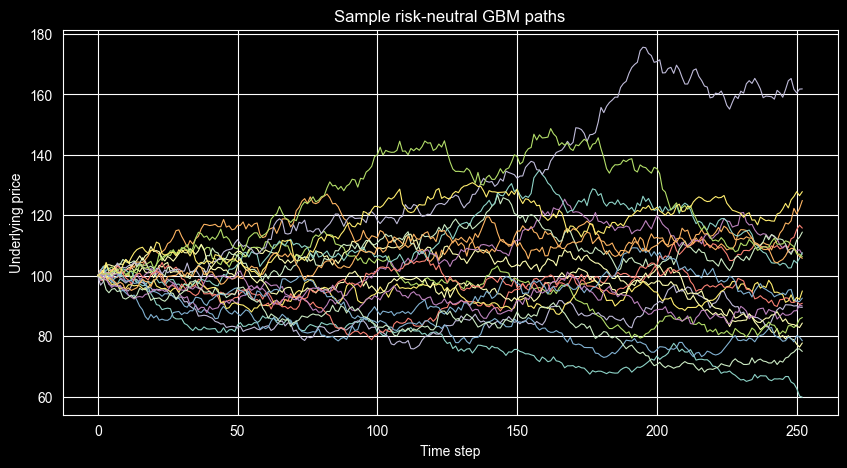

In [13]:
paths = simulate_gbm_paths(
    spot=spot,
    maturity_years=maturity_years,
    rate=rate,
    volatility=volatility,
    num_paths=25,
    num_steps=252,
    dividend_yield=dividend_yield,
    seed=7,
)

plt.figure(figsize=(10, 5))
for i in range(min(20, paths.shape[0])):
    plt.plot(paths[i], linewidth=0.8)
plt.title('Sample risk-neutral GBM paths')
plt.xlabel('Time step')
plt.ylabel('Underlying price')
plt.show()


## Monte Carlo convergence analysis

Monte Carlo error should generally decline at an approximate $1/\sqrt{N}$ rate. The confidence interval provides a practical production diagnostic: as path count increases, the standard error and interval width should shrink.

In [14]:
mc_convergence = monte_carlo_convergence_analysis(
    spot=spot,
    strike=strike,
    maturity_years=maturity_years,
    rate=rate,
    volatility=volatility,
    option_type=option_type,
    dividend_yield=dividend_yield,
    path_counts=[1_000, 2_500, 5_000, 10_000, 25_000, 50_000, 100_000],
    seed=42,
    antithetic=True,
)
mc_convergence


,num_paths,mc_price,standard_error,ci_low,ci_high,black_scholes_price,absolute_error,relative_error_pct,option_type,antithetic,seed
0,1000,10.000398,0.444738,9.128711,10.872085,10.450584,0.450186,4.307757,Call,True,42
1,2500,10.270817,0.291998,9.698501,10.843132,10.450584,0.179767,1.720162,Call,True,42
2,5000,10.450949,0.210584,10.038206,10.863693,10.450584,0.000366,0.003501,Call,True,42
3,10000,10.410052,0.147531,10.120892,10.699212,10.450584,0.040532,0.387843,Call,True,42
4,25000,10.447731,0.093678,10.264122,10.631341,10.450584,0.002852,0.027292,Call,True,42
5,50000,10.454935,0.066014,10.325547,10.584323,10.450584,0.004352,0.041641,Call,True,42
6,100000,10.467314,0.046721,10.375741,10.558888,10.450584,0.016731,0.160092,Call,True,42


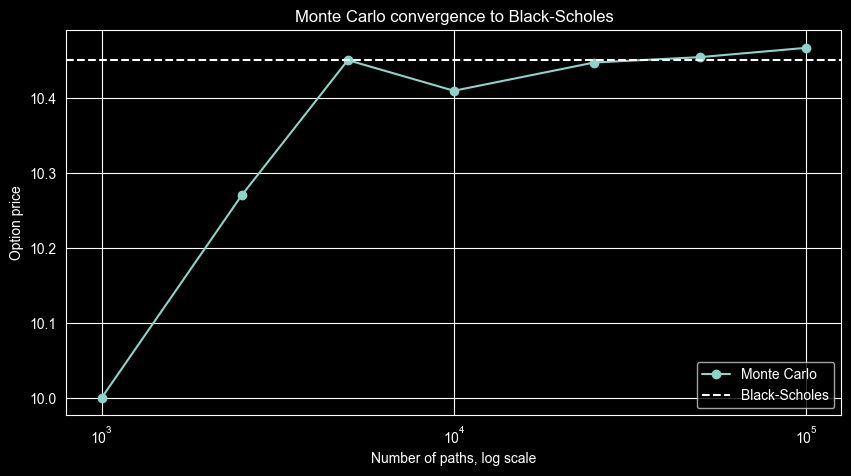

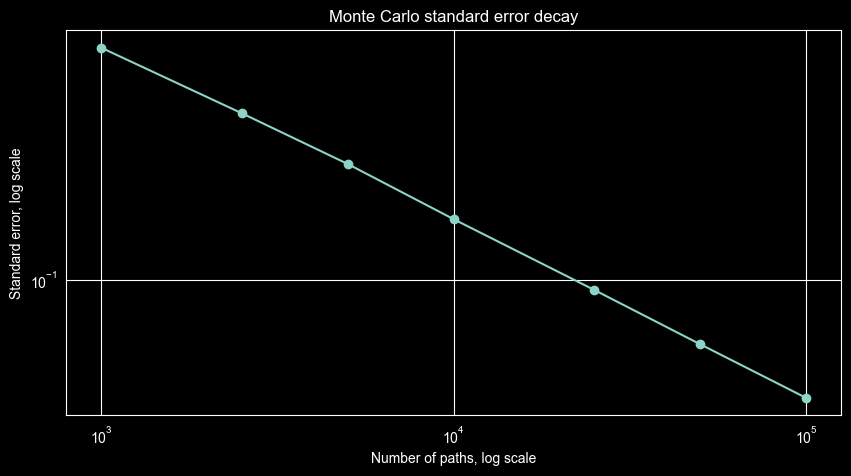

In [15]:
plt.figure(figsize=(10, 5))
plt.plot(mc_convergence['num_paths'], mc_convergence['mc_price'], marker='o', label='Monte Carlo')
plt.axhline(bs_price, linestyle='--', label='Black-Scholes')
plt.xscale('log')
plt.title('Monte Carlo convergence to Black-Scholes')
plt.xlabel('Number of paths, log scale')
plt.ylabel('Option price')
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(mc_convergence['num_paths'], mc_convergence['standard_error'], marker='o')
plt.xscale('log')
plt.yscale('log')
plt.title('Monte Carlo standard error decay')
plt.xlabel('Number of paths, log scale')
plt.ylabel('Standard error, log scale')
plt.show()


## Binomial and trinomial convergence analysis

Tree models approximate risk-neutral GBM through discrete recombining states. As the number of tree steps increases, both binomial and trinomial prices should converge toward the Black-Scholes benchmark for European options.

In [16]:
lattice_convergence = lattice_convergence_analysis(
    spot=spot,
    strike=strike,
    maturity_years=maturity_years,
    rate=rate,
    volatility=volatility,
    option_type=option_type,
    dividend_yield=dividend_yield,
    step_counts=[5, 10, 25, 50, 100, 200, 500, 1000],
)
lattice_convergence


,model,steps,tree_price,black_scholes_price,absolute_error,relative_error_pct,option_type
0,binomial,5,10.805934,10.450584,0.355350,3.400292,Call
1,trinomial,5,10.049312,10.450584,0.401272,3.839707,Call
2,binomial,10,10.253409,10.450584,0.197175,1.886732,Call
3,trinomial,10,10.257815,10.450584,0.192769,1.844572,Call
4,binomial,25,10.520966,10.450584,0.070382,0.673475,Call
5,trinomial,25,10.374792,10.450584,0.075792,0.725240,Call
6,binomial,50,10.410692,10.450584,0.039892,0.381721,Call
7,trinomial,50,10.412879,10.450584,0.037705,0.360791,Call
8,binomial,100,10.430612,10.450584,0.019972,0.191108,Call
9,trinomial,100,10.431777,10.450584,0.018807,0.179957,Call


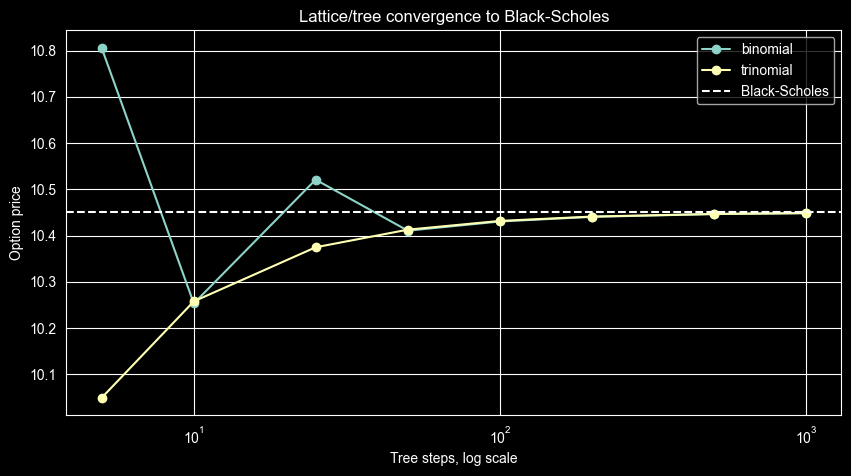

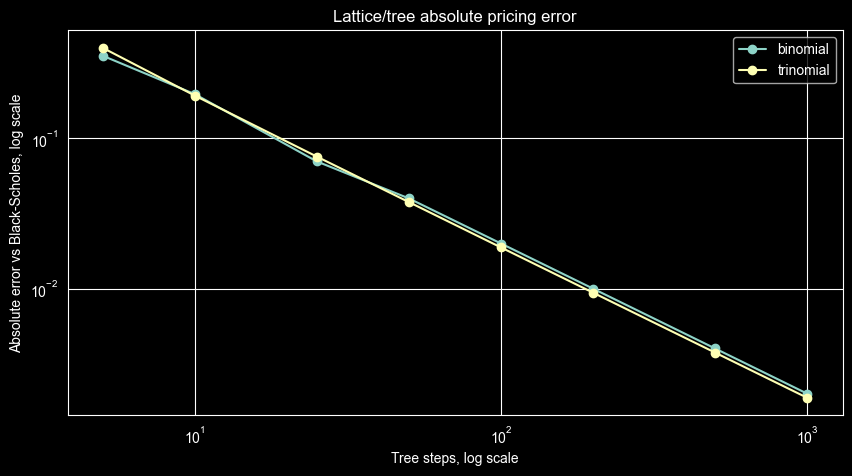

In [17]:
plt.figure(figsize=(10, 5))
for model_name, group in lattice_convergence.groupby('model'):
    plt.plot(group['steps'], group['tree_price'], marker='o', label=model_name)
plt.axhline(bs_price, linestyle='--', label='Black-Scholes')
plt.xscale('log')
plt.title('Lattice/tree convergence to Black-Scholes')
plt.xlabel('Tree steps, log scale')
plt.ylabel('Option price')
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
for model_name, group in lattice_convergence.groupby('model'):
    plt.plot(group['steps'], group['absolute_error'], marker='o', label=model_name)
plt.xscale('log')
plt.yscale('log')
plt.title('Lattice/tree absolute pricing error')
plt.xlabel('Tree steps, log scale')
plt.ylabel('Absolute error vs Black-Scholes, log scale')
plt.legend()
plt.show()


## Practical interpretation

- Black-Scholes is the analytic benchmark for European options under lognormal GBM.
- Monte Carlo is flexible and generalizes naturally to path-dependent products, but convergence is slower and must be monitored through standard errors.
- Binomial and trinomial trees provide transparent risk-neutral state evolution and backward induction. They converge quickly for European options and are useful stepping stones toward American exercise and callable structures.
- In production, store model parameters, path counts, tree steps, seeds, and pricing errors so model runs are reproducible and auditable.

### Complete Comparison Matrix
With Monte Carlo included, here is how the primary European option pricing frameworks stack up against one another:


| Model          | Type                  | Approach                      | Mathematical Core                    | Best Used For                                   | Key Advantage                                                         | Major Drawback                                           |
|----------------|:----------------------|:------------------------------|:-------------------------------------|:------------------------------------------------|:----------------------------------------------------------------------|:---------------------------------------------------------|
| Black-Scholes  | Continuous Analytical | Closed-form formula           | Partial Differential Equations (PDE) | Standard European Calls/Puts                    | Instantaneous, exact mathematical precision.                          | Rigid assumptions (constant volatility, no asset jumps). |
| Binomial (CRR) | Discrete Numerical    | Lattice (2 branches per node) | Algebra & Combinatorics              | Step-by-step visualizations                     | Highly intuitive; easily tracks early exercise (for American options).| Slow convergence; requires many steps to smooth out.     |
| Trinomial      | Discrete Numerical    | Lattice (3 branches per node) | Algebra & Matrix inversion           | Faster lattice approximations                   | Much faster convergence than Binomial with fewer steps. | Slightly more complex code to set up node probabilities. |
| Monte Carlo    | Simulation            | Random sampling               | Law of Large Numbers                 |  Complex, exotic, or multi-asset European options | Ultimate flexibility; can price almost any payoff structure. | Computationally expensive; requires heavy processing power for high accuracy. |
